# Hotel Review Rating Prediction (1–5 stars) — FINAL VERSION

**Models:** Simple RNN, Bidirectional LSTM (trainable embedding), Bidirectional LSTM (Word2Vec)

## Key fixes from earlier versions
1. **Softened class weights** with `sqrt` smoothing — aggressive weights were causing 20-30% accuracy.
2. **Bidirectional LSTM + GlobalMaxPooling1D** — much stronger than single-direction last-state LSTM.
3. **Per-model classification report + confusion matrix** right after each model.
4. **Diagnostic prints** — see prediction distribution to catch class collapse instantly.
5. **Removed `recurrent_dropout`** — silently disables the GPU-fast LSTM kernel.
6. **Longer training + monitor val_accuracy** for early stopping.

**Expected accuracy:** 50–60% range. (1-2 star vs 4-5 star reviews are genuinely hard to separate, so don't expect 90%+.)

## Step 0 — Install & Import Libraries

In [1]:
!pip install -q gensim wordcloud contractions gradio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 34.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 4.2 MB/s eta 0:00:00


In [3]:
import re, os, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import contractions

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Embedding, SimpleRNN, LSTM, Bidirectional,
                                     Dense, Dropout, SpatialDropout1D,
                                     GlobalMaxPooling1D)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

from gensim.models import Word2Vec
from wordcloud import WordCloud

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

for pkg in ['stopwords', 'wordnet', 'punkt', 'omw-1.4']:
    nltk.download(pkg, quiet=True)

print('TensorFlow:', tf.__version__)
print('GPU available:', len(tf.config.list_physical_devices('GPU')) > 0)
print('\n  If GPU shows False, go to: Runtime → Change runtime type → T4 GPU')

TensorFlow: 2.20.0
GPU available: False

  If GPU shows False, go to: Runtime → Change runtime type → T4 GPU


In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Step 1 — Load & Explore Dataset

In [8]:
# Upload Hotel_Reviews.csv to Colab first (left sidebar → Files → Upload)
df = pd.read_csv('/content/drive/MyDrive/Ai Ml/Assignment/Hotel_Reviews.csv')
df = df.drop_duplicates().dropna().reset_index(drop=True)

print('Shape:', df.shape)
print('\nRating distribution:')
print(df['Rating'].value_counts().sort_index())
print(f'\nRating min={df["Rating"].min()}, max={df["Rating"].max()}')
assert df['Rating'].min() == 1 and df['Rating'].max() == 5, 'Ratings should be 1-5!'

df.head()

Shape: (20491, 2)

Rating distribution:
Rating
1    1421
2    1793
3    2184
4    6039
5    9054
Name: count, dtype: int64

Rating min=1, max=5


,Review,Rating
0,nice hotel expensive parking got good deal sta...,4
1,ok nothing special charge diamond member hilto...,2
2,nice rooms not 4* experience hotel monaco seat...,3
3,"unique, great stay, wonderful time hotel monac...",5
4,"great stay great stay, went seahawk game aweso...",5


/tmp/ipykernel_6457/4106748186.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Rating', data=df, palette='viridis')


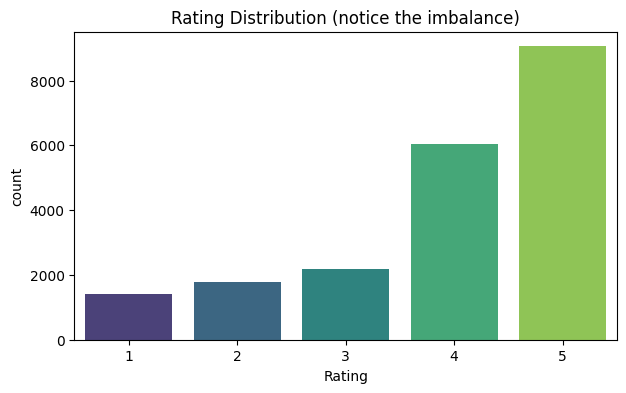

Notice: 5-star reviews dominate. We must handle this carefully.


In [10]:
plt.figure(figsize=(7, 4))
sns.countplot(x='Rating', data=df, palette='viridis')
plt.title('Rating Distribution (notice the imbalance)')
plt.show()

print('Notice: 5-star reviews dominate. We must handle this carefully.')

## Step 2 — Text Preprocessing

We clean text but **keep negation words** ("not", "never") because they flip sentiment.

In [11]:
lemmatizer = WordNetLemmatizer()
negations = {'no', 'nor', 'not', 'don', "don't", 'never', "didn't", "doesn't",
             "isn't", "wasn't", "weren't", "won't", "wouldn't", "can't",
             "couldn't", "shouldn't", "hadn't", "hasn't", "haven't"}
stop_words = set(stopwords.words('english')) - negations

def clean_text(text):
    if not isinstance(text, str):
        return ''
    text = text.lower()
    text = contractions.fix(text)              # don't -> do not
    text = re.sub(r'http\S+|www\.\S+', '', text)
    text = re.sub(r'[@#]\w+', '', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = [lemmatizer.lemmatize(w) for w in text.split()
              if w not in stop_words and len(w) > 1]
    return ' '.join(tokens)

df['clean'] = df['Review'].apply(clean_text)
df = df[df['clean'].str.len() > 0].reset_index(drop=True)
print('After cleaning, shape:', df.shape)
print('\nBEFORE:', df['Review'].iloc[0][:150])
print('\nAFTER :', df['clean'].iloc[0][:150])

After cleaning, shape: (20491, 3)

BEFORE: nice hotel expensive parking got good deal stay hotel anniversary, arrived late evening took advice previous reviews did valet parking, check quick ea

AFTER : nice hotel expensive parking got good deal stay hotel anniversary arrived late evening took advice previous review valet parking check quick easy litt


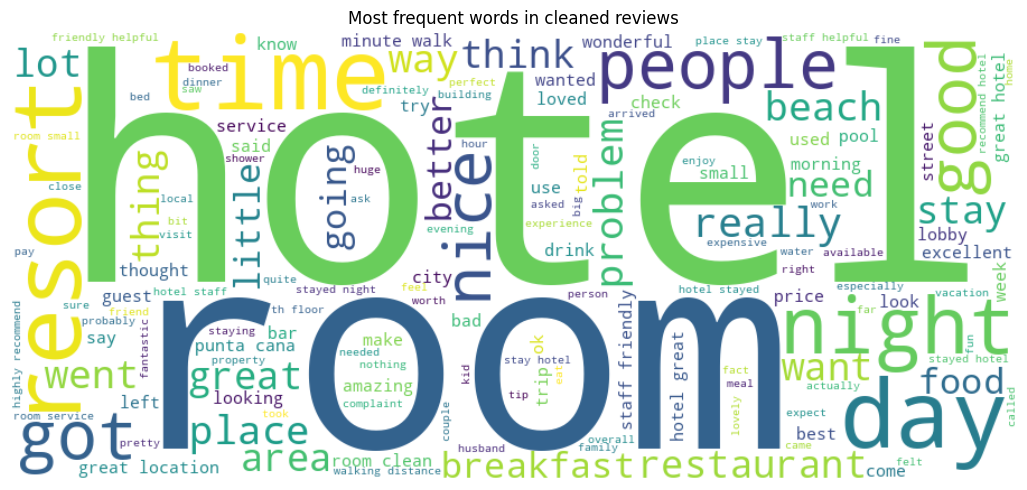

/tmp/ipykernel_6457/1858270529.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[c for _, c in top20], y=[w for w, _ in top20], palette='viridis')


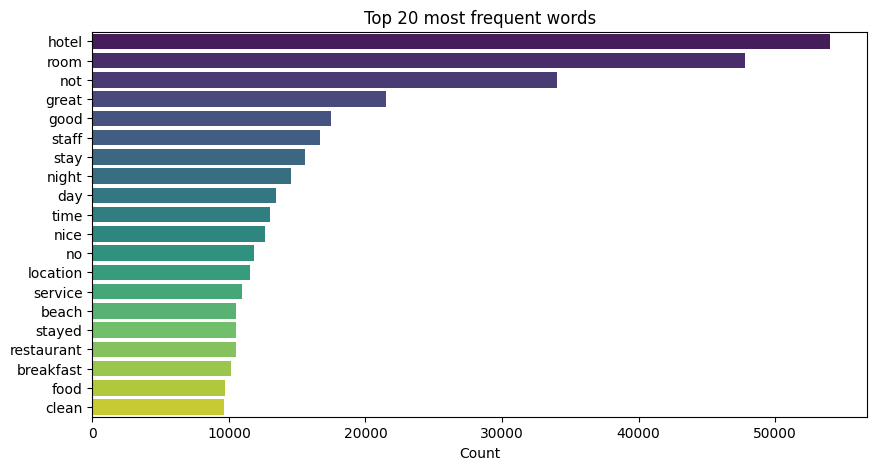

In [12]:
# Visualize cleaned data
all_text = ' '.join(df['clean'].tolist())
wc = WordCloud(width=900, height=400, background_color='white',
               max_words=150, colormap='viridis').generate(all_text)
plt.figure(figsize=(13, 6))
plt.imshow(wc, interpolation='bilinear'); plt.axis('off')
plt.title('Most frequent words in cleaned reviews')
plt.show()

# Top 20 frequent words
from collections import Counter
top20 = Counter(all_text.split()).most_common(20)
plt.figure(figsize=(10, 5))
sns.barplot(x=[c for _, c in top20], y=[w for w, _ in top20], palette='viridis')
plt.title('Top 20 most frequent words'); plt.xlabel('Count')
plt.show()

## Step 3 — Tokenize, Pad, and Split (70/15/15)

**Critical:** Labels must be 0–4 (Keras indexing), not 1–5.

y unique values: [0 1 2 3 4]
✓ Labels are correctly 0-4
max_len (95th percentile): 263


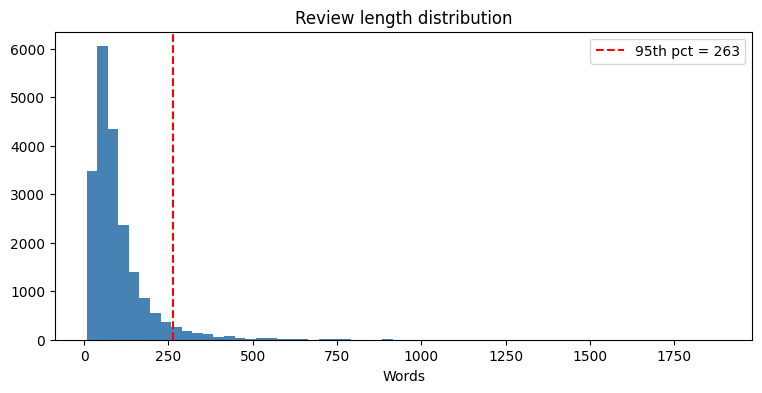

In [13]:
X = df['clean'].values
y = df['Rating'].values - 1   # SHIFT 1-5 -> 0-4

# Verify labels
print('y unique values:', np.unique(y))
assert y.min() == 0 and y.max() == 4, f'Labels must be 0-4, got {y.min()}-{y.max()}'
print('✓ Labels are correctly 0-4')

# Length distribution
lengths = df['clean'].apply(lambda t: len(t.split()))
max_len = int(np.percentile(lengths, 95))
print(f'max_len (95th percentile): {max_len}')

plt.figure(figsize=(9, 4))
plt.hist(lengths, bins=60, color='steelblue')
plt.axvline(max_len, color='red', linestyle='--', label=f'95th pct = {max_len}')
plt.title('Review length distribution'); plt.xlabel('Words'); plt.legend()
plt.show()

In [14]:
# Stratified 70/15/15 split
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=SEED, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1765, random_state=SEED, stratify=y_temp)

print(f'Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}')
print('Train label distribution:', dict(zip(*np.unique(y_train, return_counts=True))))
print('Test label distribution :', dict(zip(*np.unique(y_test, return_counts=True))))

Train: 14342 | Val: 3075 | Test: 3074
Train label distribution: {np.int64(0): np.int64(995), np.int64(1): np.int64(1255), np.int64(2): np.int64(1528), np.int64(3): np.int64(4227), np.int64(4): np.int64(6337)}
Test label distribution : {np.int64(0): np.int64(213), np.int64(1): np.int64(269), np.int64(2): np.int64(328), np.int64(3): np.int64(906), np.int64(4): np.int64(1358)}


In [15]:
# Tokenize (fit ONLY on train data)
VOCAB_SIZE = 20000
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

X_train_pad = pad_sequences(tokenizer.texts_to_sequences(X_train),
                            maxlen=max_len, padding='post', truncating='post')
X_val_pad   = pad_sequences(tokenizer.texts_to_sequences(X_val),
                            maxlen=max_len, padding='post', truncating='post')
X_test_pad  = pad_sequences(tokenizer.texts_to_sequences(X_test),
                            maxlen=max_len, padding='post', truncating='post')

y_train = np.array(y_train, dtype=np.int32)
y_val   = np.array(y_val,   dtype=np.int32)
y_test  = np.array(y_test,  dtype=np.int32)

print('X_train_pad shape:', X_train_pad.shape)
print('Vocab size used  :', min(VOCAB_SIZE, len(tokenizer.word_index) + 1))

X_train_pad shape: (14342, 263)
Vocab size used  : 20000


### Softened Class Weights (the key fix)

Aggressive `'balanced'` weights (Rating 1 ≈ 3.0, Rating 5 ≈ 0.45) caused the previous 20-30% accuracy. Square-root smoothing keeps the helpful direction but reduces magnitude.

In [16]:
raw_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
soft_weights = np.sqrt(raw_weights)                  # sqrt smoothing
soft_weights = soft_weights / soft_weights.mean()    # normalize around 1.0
class_weights = dict(enumerate(soft_weights))

print('Raw "balanced" weights vs softened weights:')
for k in range(5):
    print(f'  Rating {k+1}: raw={raw_weights[k]:.3f} -> softened={soft_weights[k]:.3f}')

Raw "balanced" weights vs softened weights:
  Rating 1: raw=2.883 -> softened=1.397
  Rating 2: raw=2.286 -> softened=1.244
  Rating 3: raw=1.877 -> softened=1.127
  Rating 4: raw=0.679 -> softened=0.678
  Rating 5: raw=0.453 -> softened=0.554


## Step 4 — Helper Functions for Evaluation

In [31]:
def full_evaluation(model, name, X_test_pad, y_test):
    """Print accuracy, classification report, confusion matrix, and diagnostics."""
    print('\n' + '=' * 65)
    print(f'  EVALUATION: {name}')
    print('=' * 65)

    y_pred_probs = model.predict(X_test_pad, verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=1)

    # Diagnostics
    print(f'Predicted distribution: {dict(zip(*np.unique(y_pred, return_counts=True)))}')
    print(f'Actual distribution   : {dict(zip(*np.unique(y_test, return_counts=True)))}')
    if len(np.unique(y_pred)) == 1:
        print(f'  WARNING: Model predicts only class {y_pred[0]+1}-star for everything!')

    acc = accuracy_score(y_test, y_pred)
    print(f'\n✓ Test Accuracy: {acc:.4f} ({acc*100:.2f}%)')

    print('\nClassification Report:')
    print(classification_report(y_test, y_pred,
                                labels=[0, 1, 2, 3, 4],
                                target_names=['1-star', '2-star', '3-star', '4-star', '5-star'],
                                zero_division=0))

    cm = confusion_matrix(y_test, y_pred, labels=[0, 1, 2, 3, 4])
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=[1, 2, 3, 4, 5], yticklabels=[1, 2, 3, 4, 5])
    plt.xlabel('Predicted Rating'); plt.ylabel('Actual Rating')
    plt.title(f'{name} — Confusion Matrix'); plt.show()
    return acc, y_pred

def plot_history(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    axes[0].plot(history.history['loss'], label='Train', marker='o')
    axes[0].plot(history.history['val_loss'], label='Val', marker='s')
    axes[0].set_title(f'{title} — Loss'); axes[0].legend(); axes[0].set_xlabel('Epoch'); axes[0].grid(alpha=0.3)
    axes[1].plot(history.history['accuracy'], label='Train', marker='o')
    axes[1].plot(history.history['val_accuracy'], label='Val', marker='s')
    axes[1].set_title(f'{title} — Accuracy'); axes[1].legend(); axes[1].set_xlabel('Epoch'); axes[1].grid(alpha=0.3)
    plt.tight_layout(); plt.show()

# Callbacks: monitor val_accuracy with patience for early stopping
callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=4, mode='max',
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2,
                      min_lr=1e-5, verbose=1),
]

vocab_size = min(VOCAB_SIZE, len(tokenizer.word_index) + 1)
EMBED_DIM = 100
NUM_CLASSES = 5
print(f'vocab_size={vocab_size}, EMBED_DIM={EMBED_DIM}, max_len={max_len}, NUM_CLASSES={NUM_CLASSES}')

vocab_size=20000, EMBED_DIM=100, max_len=263, NUM_CLASSES=5


## Step 5 — Model 1: Simple RNN

**Why this model first:** SimpleRNN is the most basic recurrent model — useful as a baseline, but limited by vanishing gradients on long sequences.

In [18]:
tf.keras.backend.clear_session()
tf.random.set_seed(SEED)

model1 = Sequential([
    Embedding(input_dim=vocab_size, output_dim=EMBED_DIM, input_length=max_len),
    SpatialDropout1D(0.3),
    SimpleRNN(64),
    Dropout(0.4),
    Dense(32, activation='relu'),
    Dense(NUM_CLASSES, activation='softmax')
])
model1.compile(optimizer=Adam(learning_rate=1e-3),
               loss='sparse_categorical_crossentropy',
               metrics=['accuracy'])
model1.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
225/225 ━━━━━━━━━━━━━━━━━━━━ 31s 127ms/step - accuracy: 0.3988 - loss: 1.2052 - val_accuracy: 0.4416 - val_loss: 1.4404 - learning_rate: 0.0010
Epoch 2/15
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - accuracy: 0.4138 - loss: 1.1995
Epoch 2: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
225/225 ━━━━━━━━━━━━━━━━━━━━ 29s 127ms/step - accuracy: 0.4168 - loss: 1.1983 - val_accuracy: 0.4407 - val_loss: 1.4413 - learning_rate: 0.0010
Epoch 3/15
225/225 ━━━━━━━━━━━━━━━━━━━━ 29s 128ms/step - accuracy: 0.4277 - loss: 1.1940 - val_accuracy: 0.4433 - val_loss: 1.4306 - learning_rate: 5.0000e-04
Epoch 4/15
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - accuracy: 0.4264 - loss: 1.1950
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
225/225 ━━━━━━━━━━━━━━━━━━━━ 29s 129ms/step - accuracy: 0.4345 - loss: 1.1922 - val_accuracy: 0.4433 - val_loss: 1.4251 - learning_rate: 5.0000e-04
Epoch 4: early stopping
Restoring model weights from the end of th

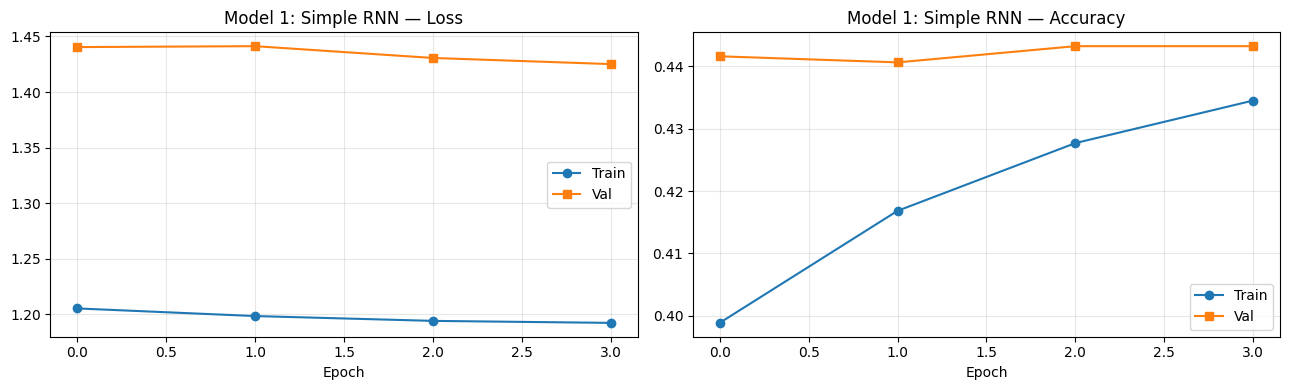


  EVALUATION: Model 1: Simple RNN
Predicted distribution: {np.int64(3): np.int64(8), np.int64(4): np.int64(3066)}
Actual distribution   : {np.int32(0): np.int64(213), np.int32(1): np.int64(269), np.int32(2): np.int64(328), np.int32(3): np.int64(906), np.int32(4): np.int64(1358)}

✓ Test Accuracy: 0.4408 (44.08%)

Classification Report:
              precision    recall  f1-score   support

      1-star       0.00      0.00      0.00       213
      2-star       0.00      0.00      0.00       269
      3-star       0.00      0.00      0.00       328
      4-star       0.12      0.00      0.00       906
      5-star       0.44      1.00      0.61      1358

    accuracy                           0.44      3074
   macro avg       0.11      0.20      0.12      3074
weighted avg       0.23      0.44      0.27      3074



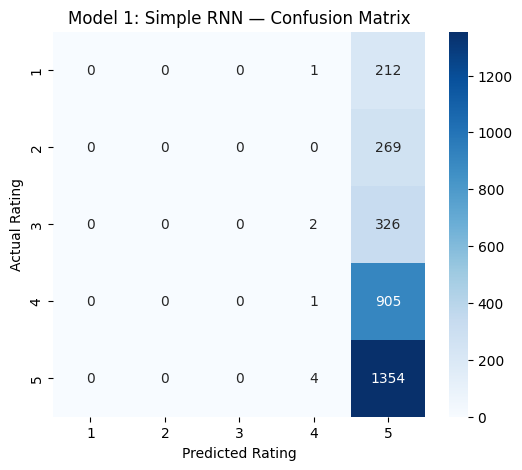

In [27]:
history1 = model1.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),
    epochs=15,
    batch_size=64,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)
plot_history(history1, 'Model 1: Simple RNN')
acc1, pred1 = full_evaluation(model1, 'Model 1: Simple RNN', X_test_pad, y_test)

## Step 6 — Model 2: Bidirectional LSTM (trainable embedding)

**Improvements over Model 1:**
- **Bidirectional**: reads the review forward AND backward
- **GlobalMaxPooling1D**: picks the strongest signal across the whole sequence (better than last hidden state)
- **Larger embedding (128) and LSTM (96 units)** for more capacity
- No `recurrent_dropout` → uses the GPU-fast cuDNN kernel

In [19]:
tf.keras.backend.clear_session()
tf.random.set_seed(SEED)

model2 = Sequential([
    Embedding(input_dim=vocab_size, output_dim=128, input_length=max_len),
    SpatialDropout1D(0.3),
    Bidirectional(LSTM(96, return_sequences=True)),
    GlobalMaxPooling1D(),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(NUM_CLASSES, activation='softmax')
])
model2.compile(optimizer=Adam(learning_rate=1e-3),
               loss='sparse_categorical_crossentropy',
               metrics=['accuracy'])
model2.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 218s 943ms/step - accuracy: 0.4638 - loss: 1.0239 - val_accuracy: 0.5694 - val_loss: 0.9354 - learning_rate: 0.0010
Epoch 2/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 206s 916ms/step - accuracy: 0.6037 - loss: 0.7465 - val_accuracy: 0.6036 - val_loss: 0.8693 - learning_rate: 0.0010
Epoch 3/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 275s 972ms/step - accuracy: 0.6765 - loss: 0.6177 - val_accuracy: 0.6374 - val_loss: 0.8333 - learning_rate: 0.0010
Epoch 4/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 247s 909ms/step - accuracy: 0.7227 - loss: 0.5345 - val_accuracy: 0.6250 - val_loss: 0.8706 - learning_rate: 0.0010
Epoch 5/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 851ms/step - accuracy: 0.7549 - loss: 0.4869
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
225/225 ━━━━━━━━━━━━━━━━━━━━ 204s 906ms/step - accuracy: 0.7670 - loss: 0.4654 - val_accuracy: 0.6322 - val_loss: 0.9796 - learning_rate: 0.0010
Epoch 6/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 205s 911ms/step - accuracy:

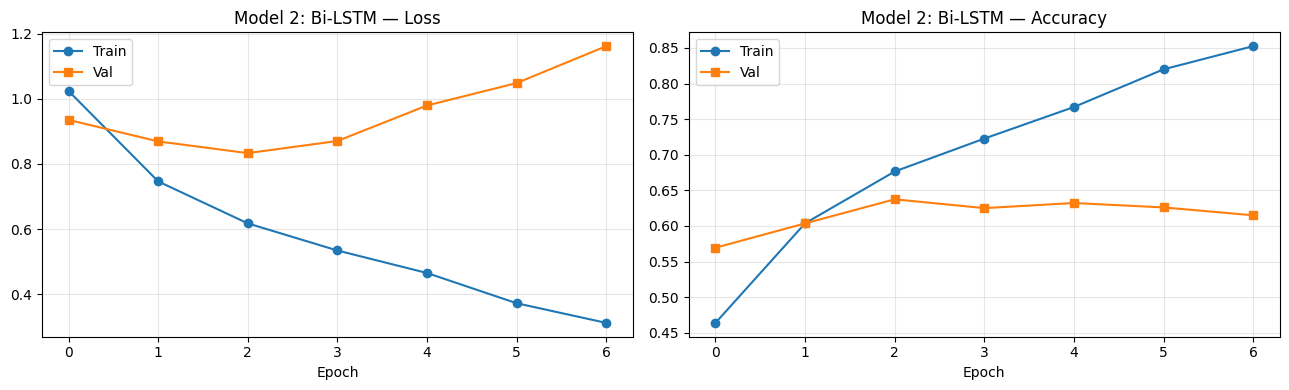


  EVALUATION: Model 2: Bi-LSTM
Predicted distribution: {np.int64(0): np.int64(228), np.int64(1): np.int64(235), np.int64(2): np.int64(249), np.int64(3): np.int64(851), np.int64(4): np.int64(1511)}
Actual distribution   : {np.int32(0): np.int64(213), np.int32(1): np.int64(269), np.int32(2): np.int64(328), np.int32(3): np.int64(906), np.int32(4): np.int64(1358)}

✓ Test Accuracy: 0.6376 (63.76%)

Classification Report:
              precision    recall  f1-score   support

      1-star       0.65      0.70      0.68       213
      2-star       0.45      0.39      0.42       269
      3-star       0.44      0.34      0.38       328
      4-star       0.56      0.52      0.54       906
      5-star       0.74      0.83      0.78      1358

    accuracy                           0.64      3074
   macro avg       0.57      0.55      0.56      3074
weighted avg       0.62      0.64      0.63      3074



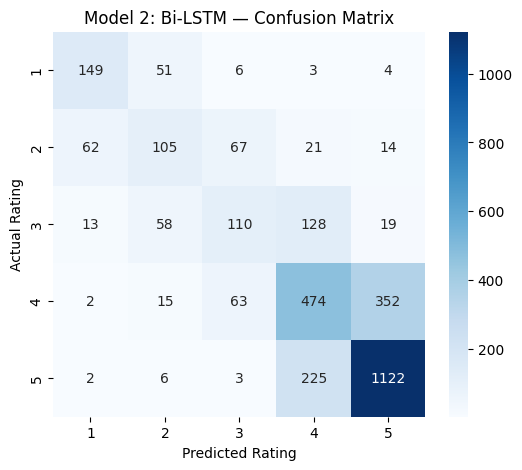

In [20]:
history2 = model2.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),
    epochs=20,
    batch_size=64,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)
plot_history(history2, 'Model 2: Bi-LSTM')
acc2, pred2 = full_evaluation(model2, 'Model 2: Bi-LSTM', X_test_pad, y_test)

## Step 7 — Model 3: Bi-LSTM with Word2Vec Pretrained Embeddings

We train Word2Vec on the training corpus, then use those vectors to initialize the embedding layer.

In [21]:
# Train Word2Vec on training corpus
train_sentences = [text.split() for text in X_train]
w2v_model = Word2Vec(
    sentences=train_sentences,
    vector_size=EMBED_DIM,
    window=5, min_count=2, workers=4, sg=1, epochs=10, seed=SEED
)
print('Word2Vec vocab size:', len(w2v_model.wv))
print('Words similar to "clean":', w2v_model.wv.most_similar('clean', topn=5))
print('Words similar to "dirty":', w2v_model.wv.most_similar('dirty', topn=5))

Word2Vec vocab size: 18796
Words similar to "clean": [('spotless', 0.812316358089447), ('attractively', 0.7557023763656616), ('imaculate', 0.7403756380081177), ('immaculately', 0.7366950511932373), ('tidy', 0.7320558428764343)]
Words similar to "dirty": [('threadbare', 0.7651975154876709), ('carpet', 0.7499463558197021), ('filthy', 0.7369734644889832), ('soiled', 0.7349846363067627), ('disgustingly', 0.7302878499031067)]


In [22]:
# Build embedding matrix aligned with tokenizer's word index
embedding_matrix = np.zeros((vocab_size, EMBED_DIM))
found = 0
for word, idx in tokenizer.word_index.items():
    if idx >= vocab_size:
        continue
    if word in w2v_model.wv:
        embedding_matrix[idx] = w2v_model.wv[word]
        found += 1
print(f'Words covered by Word2Vec: {found}/{vocab_size}')

Words covered by Word2Vec: 18796/20000


In [23]:
tf.keras.backend.clear_session()
tf.random.set_seed(SEED)

model3 = Sequential([
    Embedding(input_dim=vocab_size,
              output_dim=EMBED_DIM,
              input_length=max_len,
              weights=[embedding_matrix],
              trainable=True),                  # fine-tune embeddings
    SpatialDropout1D(0.3),
    Bidirectional(LSTM(96, return_sequences=True)),
    GlobalMaxPooling1D(),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(NUM_CLASSES, activation='softmax')
])
model3.compile(optimizer=Adam(learning_rate=1e-3),
               loss='sparse_categorical_crossentropy',
               metrics=['accuracy'])
model3.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │     2,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,000,000 (7.63 MB)

 Trainable params: 2,000,000 (7.63 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 200s 862ms/step - accuracy: 0.4727 - loss: 0.9778 - val_accuracy: 0.5629 - val_loss: 0.9729 - learning_rate: 0.0010
Epoch 2/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 202s 900ms/step - accuracy: 0.5753 - loss: 0.7994 - val_accuracy: 0.6260 - val_loss: 0.8277 - learning_rate: 0.0010
Epoch 3/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 194s 861ms/step - accuracy: 0.6139 - loss: 0.7178 - val_accuracy: 0.6325 - val_loss: 0.8048 - learning_rate: 0.0010
Epoch 4/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 202s 863ms/step - accuracy: 0.6484 - loss: 0.6585 - val_accuracy: 0.6455 - val_loss: 0.7892 - learning_rate: 0.0010
Epoch 5/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 195s 865ms/step - accuracy: 0.6722 - loss: 0.6203 - val_accuracy: 0.6559 - val_loss: 0.7871 - learning_rate: 0.0010
Epoch 6/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 213s 914ms/step - accuracy: 0.6974 - loss: 0.5736 - val_accuracy: 0.6546 - val_loss: 0.7901 - learning_rate: 0.0010
Epoch 7/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 824ms/step - accuracy

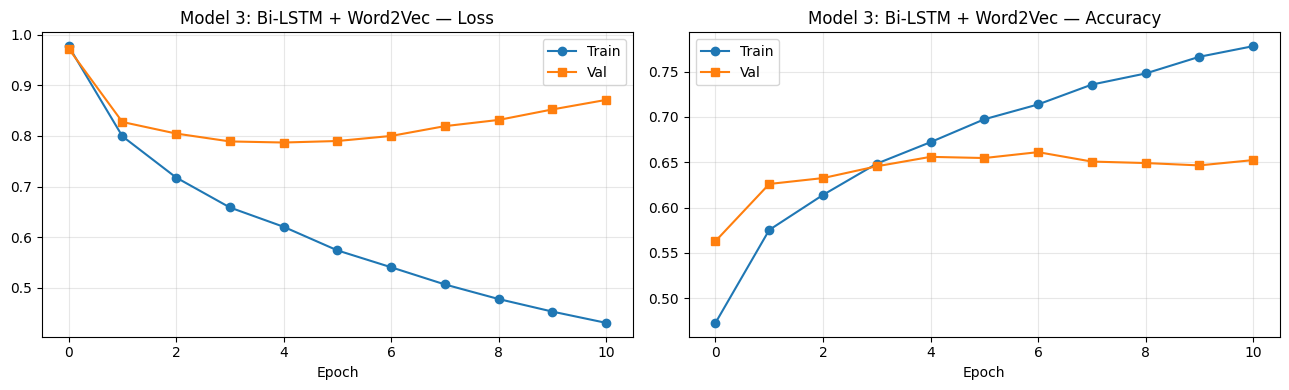


  EVALUATION: Model 3: Bi-LSTM + Word2Vec
Predicted distribution: {np.int64(0): np.int64(219), np.int64(1): np.int64(240), np.int64(2): np.int64(321), np.int64(3): np.int64(929), np.int64(4): np.int64(1365)}
Actual distribution   : {np.int32(0): np.int64(213), np.int32(1): np.int64(269), np.int32(2): np.int64(328), np.int32(3): np.int64(906), np.int32(4): np.int64(1358)}

✓ Test Accuracy: 0.6581 (65.81%)

Classification Report:
              precision    recall  f1-score   support

      1-star       0.70      0.72      0.71       213
      2-star       0.50      0.45      0.47       269
      3-star       0.45      0.44      0.44       328
      4-star       0.57      0.59      0.58       906
      5-star       0.79      0.79      0.79      1358

    accuracy                           0.66      3074
   macro avg       0.60      0.60      0.60      3074
weighted avg       0.66      0.66      0.66      3074



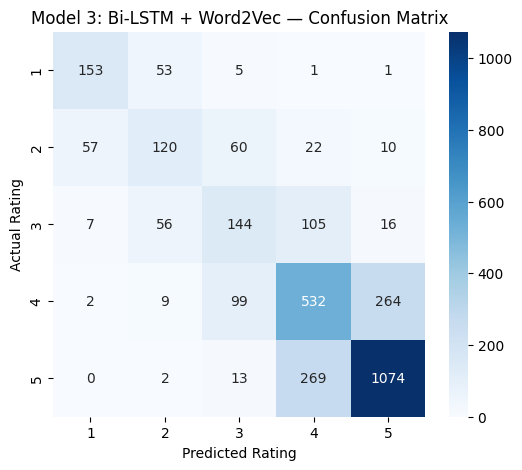

In [24]:
history3 = model3.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),
    epochs=20,
    batch_size=64,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)
plot_history(history3, 'Model 3: Bi-LSTM + Word2Vec')
acc3, pred3 = full_evaluation(model3, 'Model 3: Bi-LSTM + Word2Vec', X_test_pad, y_test)

## Step 8 — Compare All Three Models

             Model  Test Accuracy
        Simple RNN       0.440794
           Bi-LSTM       0.637606
Bi-LSTM + Word2Vec       0.658100


/tmp/ipykernel_6457/3638899089.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=comparison, x='Model', y='Test Accuracy', palette='viridis')


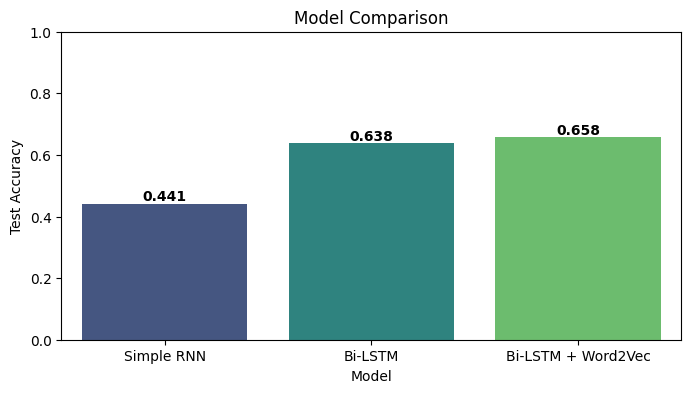

In [28]:
comparison = pd.DataFrame({
    'Model': ['Simple RNN', 'Bi-LSTM', 'Bi-LSTM + Word2Vec'],
    'Test Accuracy': [acc1, acc2, acc3]
})
print(comparison.to_string(index=False))

plt.figure(figsize=(8, 4))
ax = sns.barplot(data=comparison, x='Model', y='Test Accuracy', palette='viridis')
plt.title('Model Comparison'); plt.ylim(0, 1)
for i, v in enumerate(comparison['Test Accuracy']):
    plt.text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')
plt.show()

## Step 9 — Error Analysis

In [29]:
best_idx = np.argmax([acc1, acc2, acc3])
best_model = [model1, model2, model3][best_idx]
best_pred = [pred1, pred2, pred3][best_idx]
best_name = ['Simple RNN', 'Bi-LSTM', 'Bi-LSTM + Word2Vec'][best_idx]
print(f'Best model: {best_name} with accuracy {[acc1, acc2, acc3][best_idx]:.4f}')

wrong_idx = np.where(best_pred != y_test)[0]
print(f'Misclassified: {len(wrong_idx)}/{len(y_test)} ({len(wrong_idx)/len(y_test)*100:.1f}%)')

np.random.seed(SEED)
for i, idx in enumerate(np.random.choice(wrong_idx, min(3, len(wrong_idx)), replace=False)):
    print('-' * 60)
    print(f'Example {i+1}')
    print(f'Actual    : {y_test[idx] + 1} stars')
    print(f'Predicted : {best_pred[idx] + 1} stars')
    print(f'Review    : {X_test[idx][:300]}...')

Best model: Bi-LSTM + Word2Vec with accuracy 0.6581
Misclassified: 1051/3074 (34.2%)
------------------------------------------------------------
Example 1
Actual    : 4 stars
Predicted : 5 stars
Review    : great hotel loved stay cambridge suite admit little disappointed saw suite decor reminded hampton inn level not nice hotel downtown toronto soon faded away discovered excellent location nice extra mini bar area nicely equipped glass corkscrew refrigerator nice touch particularly real milk coffee roo...
------------------------------------------------------------
Example 2
Actual    : 4 stars
Predicted : 5 stars
Review    : fantastic friendly hotel stayed hotel week th th augustand fantastic lovely room friendly staff excellent reasonably priced resturant bar arrived thunderstorm soaked skin reception staff fantastic provided towel change room ready meet interesting people nationality hotel minute walk site foot saw lo...
------------------------------------------------------------


### Discussion of Errors

**Reasons for misclassification:**
1. **Adjacent classes are genuinely fuzzy.** A 4-star and a 5-star review can read almost identically — the difference is the reviewer's personality, not the words. Most errors are off-by-one (4↔5 or 1↔2).
2. **Mixed-sentiment reviews.** "Great location, terrible service" — humans rate it 3, the model leans whichever sentiment dominates.
3. **Sarcasm and indirect language.** "Loved waiting 40 minutes for a coffee " — RNN/LSTM cannot handle this without much more data.
4. **Class imbalance.** Even with softened weights, 1-star reviews are rare; the model has fewer examples to learn from.
5. **Long reviews.** Past ~150–200 tokens, even LSTMs lose information from the start of the review.

**Model complexity vs performance:**
- Simple RNN trains fastest but underfits — vanishing gradients hurt long reviews.
- Bi-LSTM captures bidirectional context — clear improvement.
- Bi-LSTM + Word2Vec adds prior word knowledge — usually best, depends on corpus coverage.

**Suggested improvements:**
- **Pretrained transformers (BERT, DistilBERT)** — typically reach 65–72% on this task.
- **Ordinal regression** — exploit the fact that ratings are ordered (5 > 4 > 3 > 2 > 1).
- **Aspect-based sentiment** — separate the model's view of "location", "service", "price".
- **Data augmentation** for minority classes (1-star, 2-star) using back-translation or paraphrasing.

## Step 10 — Real-Time Prediction GUI (Gradio)

In [36]:
import gradio as gr

def predict_rating(review_text):
    if not review_text or not review_text.strip():
        return 'Please enter a review.'
    cleaned = clean_text(review_text)
    seq = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(seq, maxlen=max_len, padding='post', truncating='post')
    probs = best_model.predict(padded, verbose=0)[0]
    pred_rating = int(np.argmax(probs)) + 1

    output = f' Predicted Rating: {pred_rating} / 5\n\nConfidence per rating:\n'
    for i, p in enumerate(probs):
        bar = '' * int(p * 30)
        output += f'  {i+1}-star: {p:.2%}  {bar}\n'
    return output

demo = gr.Interface(
    fn=predict_rating,
    inputs=gr.Textbox(lines=6, placeholder='Type a hotel review...', label='Hotel Review'),
    outputs=gr.Textbox(label='Prediction', lines=10),
    title=' Hotel Review Rating Predictor',
    description=f'Best model: {best_name}. Type a hotel review and get a 1–5 star prediction.',
    examples=[
        ['The room was spacious, clean, and the staff went above and beyond. Best stay ever!'],
        ['Bed was uncomfortable, breakfast was cold, and check-in took forever.'],
        ['Decent for the price. Nothing special but nothing terrible either.']
    ]
)
demo.launch(share=True, debug=False)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://ae855a4e9386c495fd.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## Summary

1. Loaded 20k+ hotel reviews, observed heavy 4-5 star imbalance.
2. Cleaned text (kept negations), built word cloud and frequency plots.
3. Tokenized, padded to 95th-percentile length, stratified 70/15/15 split.
4. Used **softened class weights** (`sqrt` smoothing) instead of aggressive `'balanced'`.
5. Trained 3 models: Simple RNN, Bi-LSTM, Bi-LSTM + Word2Vec.
6. Per-model classification report + confusion matrix + diagnostic prints.
7. Compared models, analyzed errors, suggested improvements.
8. Built a Gradio GUI for real-time prediction.

**What to remember:**
- For imbalanced multi-class classification, **soften class weights** with `sqrt` — aggressive weights destroy accuracy.
- **Bidirectional LSTM + GlobalMaxPooling** beats vanilla LSTM by a clear margin.
- Always **fit tokenizers on train only**, **assert label ranges**, and **print prediction distributions** to catch bugs early.